In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.manifold import TSNE


In [4]:
file_path = '/content/drive/MyDrive/Mall_Customers.csv'
df = pd.read_csv(file_path)


Read the CSV file from the given path and store it as a DataFrame.

In [5]:
print("First 5 rows:")
print(df.head())



First 5 rows:
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


This prints the first 5 rows of the DataFrame df, allowing you to quickly preview the data and check its structure, column values, and sample entries.

In [6]:


print("\nDataset Info:")
print(df.info())



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None


This displays a concise summary of the DataFrame, including the number of entries, column names, data types, and count of non-null values, which helps identify missing data

In [7]:
def spending_category(score):
    if score <= 33:
        return 0   # Low
    elif score <= 66:
        return 1   # Medium
    else:
        return 2   # High

df['Spending_Category'] = df['Spending Score (1-100)'].apply(spending_category)

This part defines a function spending_category that classifies customers based on their spending score into three categories: Low (0), Medium (1), and High (2). It then applies this function to the Spending Score (1-100) column of the DataFrame df and creates a new column Spending_Category containing these categorical values.

In [8]:
df = df.drop(columns=['CustomerID'])

# Convert Gender to numeric (Male=0, Female=1)
df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})



CustomerID is just an identifier and has no effect on prediction, so we remove it.
Machine learning models work with numbers.Thats why we convert categorical Gender into numeric values.

In [9]:

print(df.head())

   Gender  Age  Annual Income (k$)  Spending Score (1-100)  Spending_Category
0       0   19                  15                      39                  1
1       0   21                  15                      81                  2
2       1   20                  16                       6                  0
3       1   23                  16                      77                  2
4       1   31                  17                      40                  1


In [10]:
# Feature Scaling
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

Elbow Method

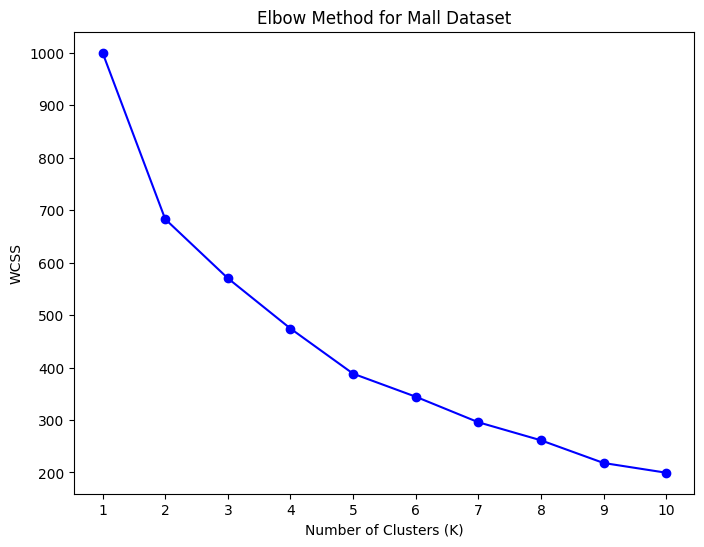

In [12]:
processed_data_df = pd.DataFrame(scaled_data, columns=df.columns)

wcss = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(processed_data_df)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,6))
plt.plot(k_range, wcss, marker='o',linestyle='-', color='b')
plt.title("Elbow Method for Mall Dataset")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.xticks(k_range)
plt.show()

This code is using the Elbow Method to find the optimal number of clusters (K) for K-Means.

It runs K-Means for different values of K (from 1 to 10) and stores the WCSS (Within-Cluster Sum of Squares).
WCSS measures how compact the clusters are (lower is better).
The graph shows how WCSS decreases as K increases

In [13]:
# Define number of clusters for K-Means
n_clusters = 6

# Apply K-Means clustering
kmeans = KMeans(n_clusters=n_clusters, max_iter=30, random_state=42)
processed_data_df['KMeans_Cluster'] = kmeans.fit_predict(processed_data_df)

# Apply DBSCAN clustering
dbscan = DBSCAN(eps=0.5, min_samples=5)
processed_data_df['DBSCAN_Cluster'] = dbscan.fit_predict(processed_data_df)

#Apply GMM clustering
gmm = GaussianMixture(n_components=n_clusters, random_state=42)
processed_data_df['GMM_Cluster'] = gmm.fit_predict(
    processed_data_df.drop(columns=['KMeans_Cluster', 'DBSCAN_Cluster'])
)

The code applies three clustering methods—K-Means, DBSCAN, and GMM—to the dataset, assigning cluster labels to each row. This lets you compare how different algorithms group the same data.

# Calculate evaluation scores

In [14]:
feature_data = processed_data_df.drop(
    columns=['KMeans_Cluster', 'DBSCAN_Cluster', 'GMM_Cluster']
)

silhouette_kmeans = silhouette_score(feature_data, processed_data_df['KMeans_Cluster'])
dbi_kmeans = davies_bouldin_score(feature_data, processed_data_df['KMeans_Cluster'])

print("KMeans Silhouette Score:", silhouette_kmeans)
print("KMeans Davies-Bouldin Index:", dbi_kmeans)

if len(set(processed_data_df['DBSCAN_Cluster'])) > 1:
    silhouette_dbscan = silhouette_score(feature_data, processed_data_df['DBSCAN_Cluster'])
    dbi_dbscan = davies_bouldin_score(feature_data, processed_data_df['DBSCAN_Cluster'])

    print("DBSCAN Silhouette Score:", silhouette_dbscan)
    print("DBSCAN Davies-Bouldin Index:", dbi_dbscan)
else:
    print("DBSCAN did not form valid clusters.")

silhouette_gmm = silhouette_score(feature_data, processed_data_df['GMM_Cluster'])
dbi_gmm = davies_bouldin_score(feature_data, processed_data_df['GMM_Cluster'])

print("GMM Silhouette Score:", silhouette_gmm)
print("GMM Davies-Bouldin Index:", dbi_gmm)

KMeans Silhouette Score: 0.3423129206126998
KMeans Davies-Bouldin Index: 1.1010146077359753
DBSCAN Silhouette Score: 0.00873999338209512
DBSCAN Davies-Bouldin Index: 1.5064003276793247
GMM Silhouette Score: 0.2569414641197857
GMM Davies-Bouldin Index: 1.188131491049182


This code evaluates the quality of clusters from K-Means, DBSCAN, and GMM using two metrics:

Silhouette Score – higher values indicate well-separated and cohesive clusters.
Davies-Bouldin Index (DBI) – lower values indicate better clustering.
It calculates these metrics for each algorithm (if DBSCAN forms valid clusters), helping compare which clustering method best fits the data.

Visualization with PCA

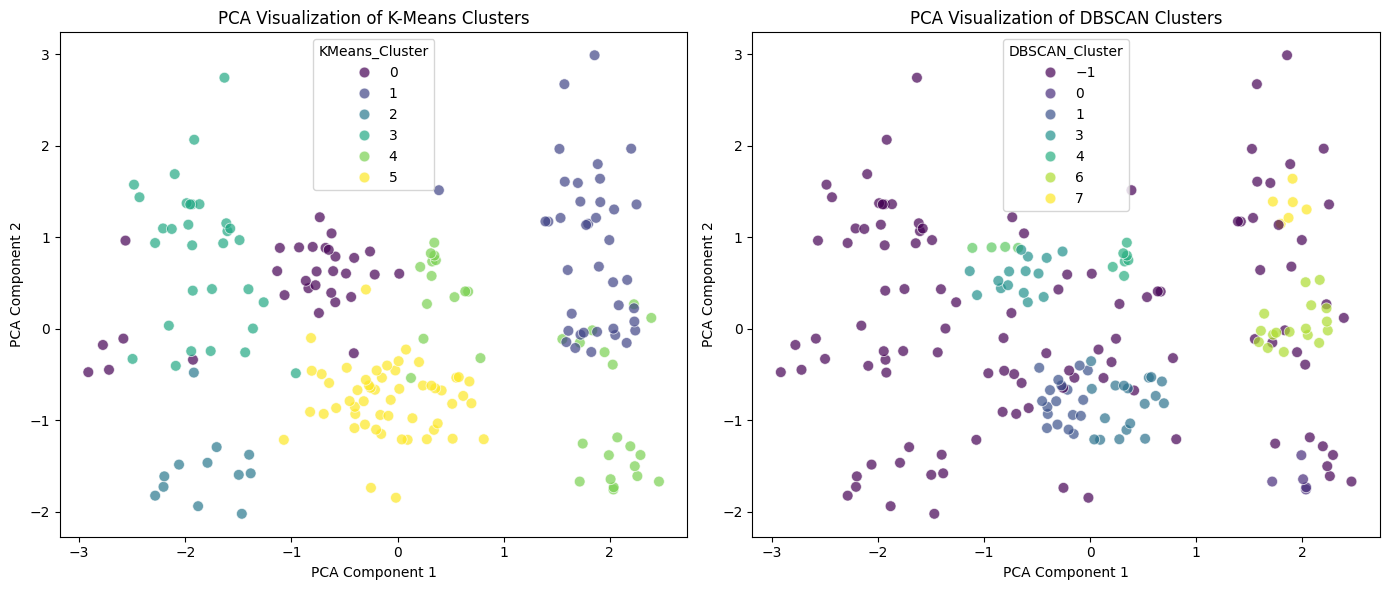

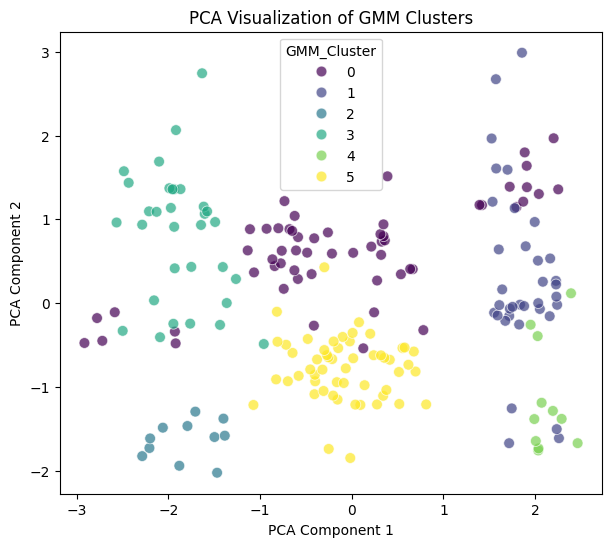

In [16]:
pca = PCA(n_components=2)
pca_components = pca.fit_transform(feature_data)

processed_data_df['PCA1'] = pca_components[:, 0]
processed_data_df['PCA2'] = pca_components[:, 1]

plt.figure(figsize=(14, 6))

# Plot for K-Means
plt.subplot(1, 2, 1)
sns.scatterplot(data=processed_data_df, x='PCA1', y='PCA2', hue='KMeans_Cluster', palette='viridis', s=60, alpha=0.7)
plt.title("PCA Visualization of K-Means Clusters")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")

# Plot for DBSCAN
plt.subplot(1, 2, 2)
sns.scatterplot(data=processed_data_df, x='PCA1', y='PCA2', hue='DBSCAN_Cluster', palette='viridis', s=60, alpha=0.7)
plt.title("PCA Visualization of DBSCAN Clusters")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")

plt.tight_layout()
plt.show()

# PCA visualization for GMM clusters
plt.figure(figsize=(7, 6))
sns.scatterplot(data=processed_data_df, x='PCA1', y='PCA2', hue='GMM_Cluster', palette='viridis', s=60, alpha=0.7)
plt.title("PCA Visualization of GMM Clusters")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()

This code visualizes the clusters found by K-Means, DBSCAN, and GMM in a 2D PCA space:
Each point represents a data sample projected onto the first two principal components (PCA1 and PCA2).
Colors indicate cluster membership for each algorithm.These plots help see how well the clusters are separated and compare clustering results visually.

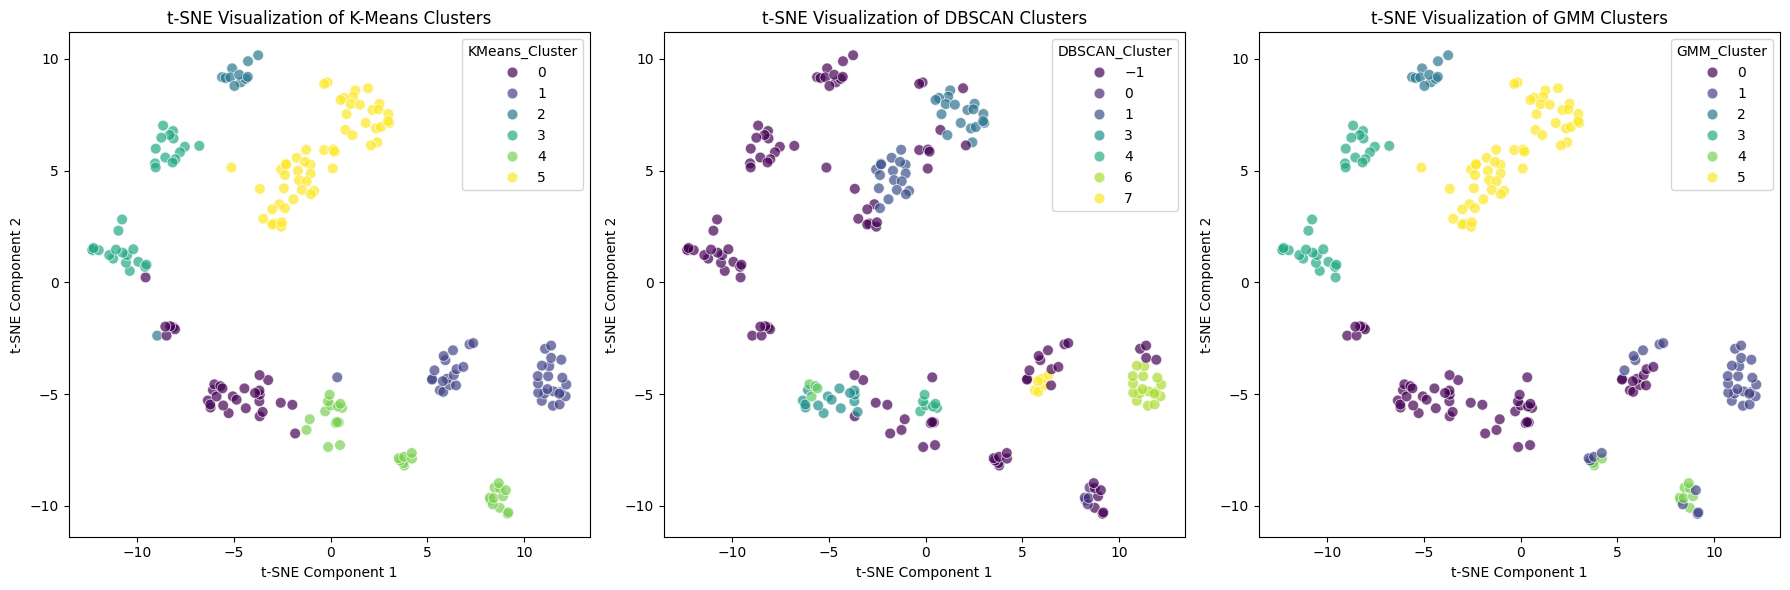

In [19]:
tsne = TSNE(n_components=2, random_state=42)
tsne_components = tsne.fit_transform(feature_data)

processed_data_df['tSNE1'] = tsne_components[:, 0]
processed_data_df['tSNE2'] = tsne_components[:, 1]

# Plot t-SNE visualization for K-Means, DBSCAN, and GMM clusters
plt.figure(figsize=(18, 6))

# Plot for K-Means
plt.subplot(1, 3, 1)
sns.scatterplot(data=processed_data_df, x='tSNE1', y='tSNE2', hue='KMeans_Cluster', palette='viridis', s=60, alpha=0.7)
plt.title("t-SNE Visualization of K-Means Clusters")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")

# Plot for DBSCAN
plt.subplot(1, 3, 2)
sns.scatterplot(data=processed_data_df, x='tSNE1', y='tSNE2', hue='DBSCAN_Cluster', palette='viridis', s=60, alpha=0.7)
plt.title("t-SNE Visualization of DBSCAN Clusters")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")

# Plot for GMM
plt.subplot(1, 3, 3)
sns.scatterplot(data=processed_data_df, x='tSNE1', y='tSNE2', hue='GMM_Cluster', palette='viridis', s=60, alpha=0.7)
plt.title("t-SNE Visualization of GMM Clusters")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")

plt.tight_layout()
plt.show()